# Benchmarking perturbation-response prediction: scvi-tools + pertpy + scib-metrics

Perturbation-response prediction — given a cell's unperturbed profile, predict its profile after a genetic or chemical perturbation — is one of the fastest-growing areas in single-cell methods, and one of the most contested. Several recent studies report that deep and foundation-model perturbation predictors fail to beat simple, parameter-free baselines on the very benchmarks they're evaluated on (e.g. [Ahlmann-Eltze et al. 2025](https://doi.org/10.1038/s41592-025-02772-6), [Wu et al. 2025](https://doi.org/10.1186/s12864-025-11600-2)). A model can only be trusted once it has demonstrably beaten a naive floor — and until now, nothing enforced that check automatically.

[`scib_metrics.perturbation`](https://scib-metrics.readthedocs.io/) is a new evaluation surface in `scib-metrics` built for exactly this: three mandatory naive baseline predictors (mean / additive / linear) plus a set of evaluation metrics — delta correlation, DE-gene rank recovery, Systema-style shared/specific decomposition, and combination-additivity — so every benchmarking run carries an honest floor to beat. It's built directly on [`pertpy`](https://pertpy.readthedocs.io/)'s perturbation-space and distance machinery rather than reimplementing it.

This tutorial shows the full stack working together on real data:

- **Data**: a real pooled CRISPR screen with single *and* double gene perturbations ([Norman et al. 2019](https://doi.org/10.1126/science.aax4438)), loaded via `pertpy`.
- **`scib_metrics.perturbation`**: the three mandatory baselines and the full metric surface, run end-to-end via `PerturbationBenchmarker`.
- **`scvi-tools`**: in the optional advanced section, we train a real generative perturbation-response model — [scGen](https://doi.org/10.1038/s41592-019-0494-8), exposed by `pertpy` as `pt.tl.Scgen` and built directly on scvi-tools' model base classes — and ask whether it beats the naive floor.

```{note}
Running the following cell will install tutorial dependencies on Google Colab only. It will have no effect on environments other than Google Colab.
```

In [1]:
!pip install --quiet scvi-colab
from scvi_colab import install

install()


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


/opt/miniconda3/envs/scvi_new/lib/python3.12/site-packages/scvi_colab/_core.py:47: UserWarning: 
                Not currently in Google Colab environment.

                Please run with `run_outside_colab=True` to override.

                Returning with no further action.
                
  warn(


`scib_metrics.perturbation` depends on `pertpy`, which is not installed by default alongside `scvi-tools`. Install it with the `perturbation` extra:

In [2]:
%pip install --quiet "scib-metrics[perturbation]"


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


## Imports

In [3]:
import warnings
from importlib.metadata import version

warnings.filterwarnings("ignore")

import numpy as np
import pertpy as pt
import scanpy as sc
import scib_metrics
import scvi
import torch
from scib_metrics.perturbation import (
    PerturbationBaselines,
    PerturbationBenchmarker,
    PerturbationMetrics,
)

```{note}
Real Perturb-seq datasets and generative models are compute-hungry. This tutorial is written to run end-to-end on a laptop CPU with a small gene panel, a small cell budget, and (in the advanced section) very few training epochs — enough to validate that every step works correctly, not to reproduce publication-quality numbers. If you have GPU access, re-run the advanced section with more epochs, `accelerator="gpu"`, and a larger gene panel for numbers you can actually draw conclusions from.
```

In [4]:
scvi.settings.seed = 0
print("Last run with scvi-tools version:", scvi.__version__)
print("Last run with pertpy version:", version("pertpy"))
print("Last run with scib-metrics version:", scib_metrics.__version__)

Seed set to 0


Last run with scvi-tools version: 1.5.0.post1
Last run with pertpy version: 1.2.0
Last run with scib-metrics version: 0.6.0


## Load the data: Norman et al. 2019 pooled CRISPR screen

Norman et al. performed a pooled CRISPR-activation screen in K562 cells, profiling cells that received *no* perturbation (`control`), a *single* gene perturbation (e.g. `CEBPE`), or a *pair* of simultaneous perturbations (e.g. `CEBPE+RUNX1T1`) — precisely to study how pairs of perturbations combine. `pertpy` ships a processed version of this dataset; the first call downloads and caches it (~1.7 GB).

In [5]:
adata = pt.dt.norman_2019()
adata

AnnData object with n_obs × n_vars = 111255 × 19018
    obs: 'guide_identity', 'read_count', 'UMI_count', 'coverage', 'gemgroup', 'good_coverage', 'number_of_cells', 'guide_AHR', 'guide_ARID1A', 'guide_ARRDC3', 'guide_ATL1', 'guide_BAK1', 'guide_BCL2L11', 'guide_BCORL1', 'guide_BPGM', 'guide_C19orf26', 'guide_C3orf72', 'guide_CBFA2T3', 'guide_CBL', 'guide_CDKN1A', 'guide_CDKN1B', 'guide_CDKN1C', 'guide_CEBPA', 'guide_CEBPB', 'guide_CEBPE', 'guide_CELF2', 'guide_CITED1', 'guide_CKS1B', 'guide_CLDN6', 'guide_CNN1', 'guide_CNNM4', 'guide_COL1A1', 'guide_COL2A1', 'guide_CSRNP1', 'guide_DLX2', 'guide_DUSP9', 'guide_EGR1', 'guide_ELMSAN1', 'guide_ETS2', 'guide_FEV', 'guide_FOSB', 'guide_FOXA1', 'guide_FOXA3', 'guide_FOXF1', 'guide_FOXL2', 'guide_FOXO4', 'guide_GLB1L2', 'guide_HES7', 'guide_HK2', 'guide_HNF4A', 'guide_HOXA13', 'guide_HOXB9', 'guide_HOXC13', 'guide_IER5L', 'guide_IGDCC3', 'guide_IKZF3', 'guide_IRF1', 'guide_ISL2', 'guide_JUN', 'guide_KIAA1804', 'guide_KIF18B', 'guide_KIF2C', '

`adata.obs['perturbation_name']` holds the perturbation identity of each cell, with `"control"` marking unperturbed cells and `"+"` joining the names of a double perturbation (e.g. `"CEBPE+RUNX1T1"`) — which is exactly `scib_metrics.perturbation`'s default separator convention, so no renaming is needed.

In [6]:
adata.obs["perturbation_name"].value_counts().head(15)

perturbation_name
control          11835
KLF1              1954
BAK1              1451
CEBPE             1230
CEBPE+RUNX1T1     1215
ETS2              1201
UBASH3B           1201
TBX2+TBX3         1164
OSR2              1002
SLC4A1             998
SET                985
ELMSAN1            935
CNN1+ETS2          904
MAP2K6             878
FOXF1              873
Name: count, dtype: int64

The full screen has 237 distinct perturbations. For a tutorial that runs end-to-end on a laptop, we pick a small, real, well-represented slice: four single-gene perturbations (`CEBPE`, `RUNX1T1`, `OSR2`, `UBASH3B`) to train on, and their two combinations (`CEBPE+RUNX1T1`, `OSR2+UBASH3B`) held out entirely — the model and every baseline will see the two genes in isolation during training, but never see them measured together. Predicting the held-out combination from the trained singles is exactly the generalization task `scib_metrics.perturbation` is built to evaluate. We hold out *two* combinations (not one) so that the Systema-style shared/specific decomposition metric — which needs at least two held-out perturbations to estimate a shared component — actually runs.

In [7]:
train_singles = ["CEBPE", "RUNX1T1", "OSR2", "UBASH3B"]
held_out_combos = ["CEBPE+RUNX1T1", "OSR2+UBASH3B"]

subset = adata[
    adata.obs["perturbation_name"].isin(["control", *train_singles, *held_out_combos])
].copy()
subset.obs["perturbation_name"].value_counts()

perturbation_name
control          11835
CEBPE             1230
CEBPE+RUNX1T1     1215
UBASH3B           1201
OSR2              1002
OSR2+UBASH3B       795
RUNX1T1            777
Name: count, dtype: int64

`control` cells vastly outnumber every perturbed group here — subsample them down for speed and balance, a standard step when working with Perturb-seq control pools.

In [8]:
rng = np.random.default_rng(0)
control_mask = subset.obs["perturbation_name"] == "control"
control_idx = np.where(control_mask)[0]
keep_control_idx = rng.choice(control_idx, size=1200, replace=False)
keep_idx = np.concatenate([keep_control_idx, np.where(~control_mask)[0]])
subset = subset[keep_idx].copy()
subset.obs["perturbation_name"].value_counts()

perturbation_name
CEBPE            1230
CEBPE+RUNX1T1    1215
UBASH3B          1201
control          1200
OSR2             1002
OSR2+UBASH3B      795
RUNX1T1           777
Name: count, dtype: int64

Split into a training set (control + the four trained singles) and a held-out test set (the two combinations only) — `PerturbationBenchmarker` never sees the test set's perturbation identities during training, matching a genuine generalization evaluation. We also restrict to a highly-variable-gene panel computed on the *training* set alone: selecting genes using the test set would leak information about the held-out combinations into gene selection before any prediction happens.

In [9]:
train = subset[subset.obs["perturbation_name"].isin(["control", *train_singles])].copy()
test = subset[subset.obs["perturbation_name"].isin(held_out_combos)].copy()

sc.pp.highly_variable_genes(train, n_top_genes=1000)
hvg_genes = train.var_names[train.var["highly_variable"]]
train = train[:, hvg_genes].copy()
test = test[:, hvg_genes].copy()
train.shape, test.shape

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


((5410, 1000), (2010, 1000))

## The floor: mandatory naive baselines

`scib_metrics.perturbation` ships three baseline predictors that any real model should beat before being trusted:

- **`MeanBaseline`** — predicts the mean training-perturbation delta for every requested perturbation, blind to which one is asked for. The literature's "did your model beat just guessing the average perturbed profile" floor.
- **`AdditiveBaseline`** — for a held-out perturbation that decomposes into trained singles (like our two combos), predicts the sum of the two singles' effects; falls back to `MeanBaseline`'s behavior otherwise.
- **`LinearBaseline`** — ridge regression from a perturbation *encoding* to its expression delta; the only baseline that can generalize from a feature encoding alone.

`LinearBaseline` needs a feature vector per perturbation. A natural, minimal choice here is a one-hot encoding over the four trained genes, with a combination's encoding as the union (multi-hot) of its components — `"CEBPE+RUNX1T1"` gets both the `CEBPE` and `RUNX1T1` indicators set.

In [10]:
perturbation_encodings = {
    "CEBPE": np.array([1.0, 0.0, 0.0, 0.0]),
    "RUNX1T1": np.array([0.0, 1.0, 0.0, 0.0]),
    "OSR2": np.array([0.0, 0.0, 1.0, 0.0]),
    "UBASH3B": np.array([0.0, 0.0, 0.0, 1.0]),
    "CEBPE+RUNX1T1": np.array([1.0, 1.0, 0.0, 0.0]),
    "OSR2+UBASH3B": np.array([0.0, 0.0, 1.0, 1.0]),
}

## Running the benchmarker

In [11]:
benchmarker = PerturbationBenchmarker(
    train,
    test,
    target_col="perturbation_name",
    reference_key="control",
    perturbation_encodings=perturbation_encodings,
    baselines=PerturbationBaselines(),
    metrics=PerturbationMetrics(),
)
benchmarker.benchmark()
benchmarker.get_results()

,is_baseline,delta_correlation,systema_shared,systema_specific
mean,True,0.750049,0.942643,0.000000
additive,True,0.915608,0.942643,0.948817
linear,True,0.915608,0.942643,0.948817


Every row here is a naive baseline — no real model has been trained yet, and already there's a nontrivial floor: `MeanBaseline` gets `delta_correlation` partway there just from the average perturbed profile, but scores exactly `0.0` on `systema_specific` — it is mathematically incapable of saying anything about a perturbation's *specific* effect, only the shared systematic shift. `AdditiveBaseline` and `LinearBaseline` score identically here: with an orthogonal one-hot encoding and no additional regularization signal, ridge regression's prediction for a combination *is* the sum of its components' coefficients — `LinearBaseline` reduces to `AdditiveBaseline`'s behavior under this particular encoding, a good illustration of why the specific encoding you choose matters.

`combination_additivity` is a diagnostic, not a headline score: for each held-out combination, it reports how far the *measured* combined effect is from the simple sum of its two components' *measured* effects — a large distance flags a genuine genetic interaction (epistasis), not a modeling failure.

In [12]:
benchmarker.get_combination_additivity()

,distance,predicted_magnitude,measured_magnitude
CEBPE+RUNX1T1,0.026177,5.078570,2.887529
OSR2+UBASH3B,0.142606,2.573655,1.760537


The two held-out pairs show different additivity: whichever combination has the larger `distance` here is the one whose two genes interact non-additively when perturbed together — exactly the kind of genetic-interaction signal Norman et al. designed this screen to detect. No baseline can be expected to predict a strongly non-additive pair well; `combination_additivity` tells you which pair to expect that for *before* judging a model's `delta_correlation` score on it.

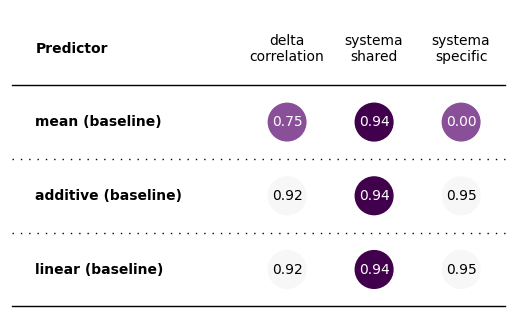

In [13]:
benchmarker.plot_results_table()

## (Advanced) Does a real scvi-tools-based model beat the floor?

```{note}
This section is more advanced and more experimental than the rest of the tutorial. It trains a real generative model and combines its predictions in a way that mirrors an internal implementation detail of `pertpy`'s `Scgen.predict()`, rather than a fully public, guaranteed-stable API — treat it as a demonstration of the *idea*, not a drop-in production pipeline. The rest of the tutorial does not depend on this section.
```

[scGen](https://doi.org/10.1038/s41592-019-0494-8) is a variational-autoencoder-based perturbation-response model: it embeds cells into a latent space, computes the average shift a perturbation induces in that latent space, and predicts a new cell's perturbed profile by adding that shift to its latent embedding before decoding. `pertpy` exposes it as `pt.tl.Scgen`, built directly on scvi-tools' model base classes — the same `setup_anndata` / model / `train()` pattern as any scvi-tools model.

Notice that scGen's own mechanism — add a shift vector, then decode — is a *latent-space* version of exactly what `AdditiveBaseline` does directly in gene-expression-delta space. That makes it a natural, fair comparison: does moving the additive assumption into a learned latent space actually help?

In [14]:
train.obs["perturbation_name"] = train.obs["perturbation_name"].astype(str).astype("category")
pt.tl.Scgen.setup_anndata(train, batch_key="perturbation_name", labels_key=None)
scgen_model = pt.tl.Scgen(train, n_hidden=128, n_latent=20)

Train briefly — three epochs on CPU is enough to confirm the pipeline runs correctly, **not** enough for the model to have learned anything reliable yet. Increase `max_epochs` substantially (and switch to `accelerator="gpu"`) to get a scientifically meaningful comparison.

In [15]:
scgen_model.train(max_epochs=3, batch_size=128, accelerator="cpu")

GPU available: True (mps), used: False


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs


Training:   0%|          | 0/3 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=3` reached.


`Scgen.predict()` computes a perturbation's shift as `latent(perturbed) - latent(control)` and is designed to apply *one* such shift to a new set of cells. To predict a *combination* it was never trained on, we compute each component gene's shift separately and add both shifts to the control latent representation before a single decode — the same latent-additivity idea `AdditiveBaseline` uses, just one level deeper in the model.

In [16]:
ctrl_cells = train[train.obs["perturbation_name"] == "control"].copy()
latent_ctrl = scgen_model.get_latent_representation(ctrl_cells)
ctrl_mean_expression = np.asarray(scgen_model.get_decoded_expression(ctrl_cells)).mean(axis=0)

scgen_predicted_deltas = {}
for combo in held_out_combos:
    genes = combo.split("+")
    latent_deltas = []
    for gene in genes:
        _, latent_delta = scgen_model.predict(
            ctrl_key="control", stim_key=gene, adata_to_predict=ctrl_cells
        )
        latent_deltas.append(np.asarray(latent_delta))
    combined_latent = latent_ctrl + sum(latent_deltas)
    with torch.no_grad():
        decoded = scgen_model.module.as_bound().generative(
            torch.as_tensor(combined_latent, dtype=torch.float32)
        )["px"]
    predicted_mean_expression = np.asarray(decoded).mean(axis=0)
    scgen_predicted_deltas[combo] = predicted_mean_expression - ctrl_mean_expression

scgen_predictions = np.stack([scgen_predicted_deltas[combo] for combo in held_out_combos])
scgen_predictions.shape

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


INFO     Received view of anndata, making copy.                                                                    


INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


INFO     Received view of anndata, making copy.                                                                    


INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


...

INFO     Received view of anndata, making copy.                                                                    


INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


INFO     Received view of anndata, making copy.                                                                    


INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


(2, 1000)

Feed scGen's predictions into a fresh `PerturbationBenchmarker` alongside the same three baselines, via the `predictions` argument — exactly how you'd plug in any model of your own.

In [17]:
benchmarker_with_scgen = PerturbationBenchmarker(
    train,
    test,
    target_col="perturbation_name",
    reference_key="control",
    perturbation_encodings=perturbation_encodings,
    predictions={"scgen": scgen_predictions},
    baselines=PerturbationBaselines(),
    metrics=PerturbationMetrics(),
)
benchmarker_with_scgen.benchmark()
benchmarker_with_scgen.get_results()

,is_baseline,delta_correlation,systema_shared,systema_specific
mean,True,0.750049,0.942643,0.000000
additive,True,0.915608,0.942643,0.948817
linear,True,0.915608,0.942643,0.948817
scgen,False,0.054332,0.090353,0.108481


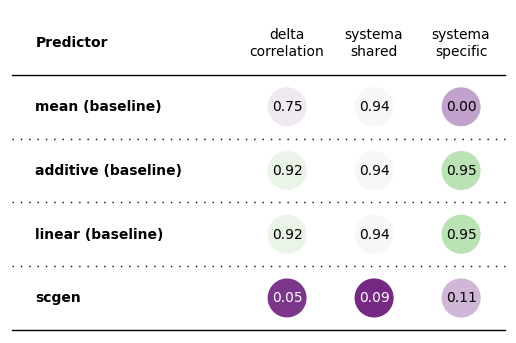

In [18]:
benchmarker_with_scgen.plot_results_table()

With only three training epochs on a tiny gene panel, don't expect `scgen` to clearly beat the naive baselines here — and that's the point of this module: the naive floor is there precisely so a claim like "our model predicts perturbation responses well" has to clear a real bar, not just look plausible on a UMAP. Re-run this section with far more training and a full gene panel on a GPU, and see whether that changes.

## Summary

- `scib_metrics.perturbation.PerturbationBenchmarker` runs mandatory naive baselines (mean / additive / linear) and your own model's predictions through a shared evaluation surface — delta correlation, Systema-style shared/specific decomposition, and combination-additivity — so every perturbation-prediction claim carries an honest floor.
- It's built directly on `pertpy`'s perturbation-space and distance machinery, so real `pertpy` datasets and workflows plug in with no glue code.
- A real scvi-tools-based model (`pertpy`'s `Scgen`) plugs into the same `predictions=` argument as any other model, letting you compare a deep generative model against the naive floor directly.

### References

- Norman, T. M. et al. ["Exploring genetic interaction manifolds constructed from rich single-cell phenotypes."](https://doi.org/10.1126/science.aax4438) Science 365, 786–793 (2019).
- Ahlmann-Eltze, C. et al. ["Deep-learning-based gene perturbation effect prediction does not yet outperform simple linear baselines."](https://doi.org/10.1038/s41592-025-02772-6) Nature Methods (2025).
- Xu, C. et al. ["scGen predicts single-cell perturbation responses."](https://doi.org/10.1038/s41592-019-0494-8) Nature Methods 16, 715–721 (2019).
- [`scib_metrics.perturbation` API reference](https://scib-metrics.readthedocs.io/en/stable/api.html)
- [`pertpy` documentation](https://pertpy.readthedocs.io/)